<a href="https://colab.research.google.com/github/OlekanmaVictoria/Artificial-intelligence-Data-science-Portfolio/blob/main/Recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Course Recommendation System Using Machine Learning**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Load dataset
file_path = "/content/coursera_courses.csv"
df = pd.read_csv(file_path)

In [3]:
# Display basic dataset information
print("Dataset Overview:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   course_title              1000 non-null   object 
 1   course_organization       1000 non-null   object 
 2   course_certificate_type   1000 non-null   object 
 3   course_time               1000 non-null   object 
 4   course_rating             994 non-null    float64
 5   course_reviews_num        994 non-null    object 
 6   course_difficulty         1000 non-null   object 
 7   course_url                1000 non-null   object 
 8   course_students_enrolled  959 non-null    object 
 9   course_skills             1000 non-null   object 
 10  course_summary            1000 non-null   object 
 11  course_description        999 non-null    object 
dtypes: float64(1), object(11)
memory usage: 93.9+ KB
None

Missing Values:
course_title                 0

In [4]:
# Fill missing values in relevant columns
df["course_skills"].fillna("", inplace=True)
df["course_summary"].fillna("", inplace=True)
df["course_description"].fillna("", inplace=True)

<ipython-input-4-78ec089a61a0>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["course_skills"].fillna("", inplace=True)
<ipython-input-4-78ec089a61a0>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

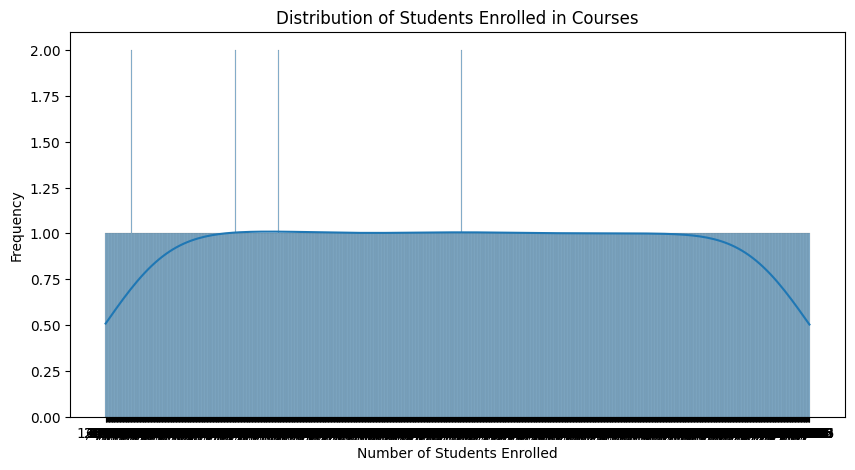

In [5]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(10,5))
sns.histplot(df['course_students_enrolled'], bins=30, kde=True)
plt.title("Distribution of Students Enrolled in Courses")
plt.xlabel("Number of Students Enrolled")
plt.ylabel("Frequency")
plt.show()

In [6]:
# Combine text fields for content-based filtering
df["combined_text"] = (
    df["course_title"] + " " + df["course_skills"] + " " + df["course_summary"] + " " + df["course_description"]
)

In [7]:
# Apply TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["combined_text"])

In [8]:
# Compute Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)


In [9]:
# Function to get course recommendations
def recommend_courses(course_title, num_recommendations=5):
    if course_title not in df["course_title"].values:
        return "Course not found. Please try another."

    # Get index of the course
    title_index = df[df["course_title"] == course_title].index[0]

    # Get similarity scores for all courses
    sim_scores = list(enumerate(cosine_sim[title_index]))

    # Sort courses based on similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top recommended courses (excluding itself)
    sim_scores = sim_scores[1:num_recommendations+1]

    # Get recommended course titles
    recommended_courses = [df.iloc[i[0]]["course_title"] for i in sim_scores]
    return recommended_courses


In [10]:
# Example usage
example_course = df["course_title"].iloc[0]  # Pick a random course
print(f"Recommendations for: {example_course}")
print(recommend_courses(example_course))

Recommendations for: (ISC)² Systems Security Certified Practitioner (SSCP)
['ChatGPT for Beginners: Save time with Microsoft Excel', 'IT Security: Defense against the digital dark arts', 'Security Principles', 'Preparing for Google Cloud Certification: Cloud Security Engineer', 'Cybersecurity Risk Management Frameworks']
